<a href="https://colab.research.google.com/github/18252054-sketch/eda_projeto_ia/blob/main/eda_projeto_ia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Análise Exploratória de Dados (AV1)

**Alunos:** Renato Alves - Emerson Tonial - José Carlos Lima  
**Disciplina:** Inteligência Artificial / Análise de Dados  
**Professor:** Kelvin Frade  

---

# **1) Introdução e Escolha da Base de Dados**

Para este projeto de Análise Exploratória de Dados (EDA), foi selecionado o dataset **"Sofascore and Transfermarkt Football Data"** obtido no Kaggle.



### Validação dos Critérios Mínimos:
* **Volume de Registros:** A base `statistics_player.csv` contém **39.861 registros** (mínimo exigido: 10.000).
* **Variáveis (Features):** Conta com **53 colunas**, permitindo uma análise aprofundada do desempenho dos atletas.
* **Diversidade de Domínios:**
  * **Categorias / Textos:** `position` (Posição), `team_name` (Clube), `country` (País), `campeonato`.
  * **Datas:** `data_jogo` e `dateOfBirth`.
  * **Numéricas Discretas:** `goals`, `fouls`, `yellowCard`, `jerseyNumber`.
  * **Numéricas Contínuas:** `rating` (Nota Sofascore), `expectedGoals` (xG), `height` (Altura).

https://www.kaggle.com/datasets/felipesembay/sofascore-and-transfermarkt-football-data


# **Interesse no Conjunto de Dados:**

O futebol brasileiro é um domínio rico em dados estatísticos e táticos. O interesse nesta base reside na oportunidade de integrar métricas de desempenho desportivo individual e coletivo (Sofascore) com dados de contexto de mercado e partidas (Transfermarkt). A análise permite examinar o rendimento de atletas nas principais competições nacionais (Séries A e B do Campeonato Brasileiro e Copa do Brasil), com foco especial em compreender os fatores que influenciam as notas de desempenho dos jogadores e avaliar a presença e impacto dos clubes.


In [26]:
import os
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [27]:
# 1. Download do dataset do Kaggle
path = kagglehub.dataset_download("felipesembay/sofascore-and-transfermarkt-football-data")
print("Caminho dos ficheiros:", path)

# 2. Listar todos os ficheiros CSV disponíveis na base
ficheiros = os.listdir(path)
print("\nFicheiros CSV encontrados na base:")
for f in ficheiros:
    print(f"- {f}")

# 3. Exemplo: Carregar a tabela de estatísticas de jogadores (statistics_player.csv)
csv_player_stats = os.path.join(path, "statistics_player.csv")

if os.path.exists(csv_player_stats):
    df_players = pd.read_csv(csv_player_stats)

    print("\n=== VALIDAÇÃO DA TABELA STATISTICS_PLAYER ===")
    print(f"Total de Linhas: {df_players.shape[0]}")
    print(f"Total de Colunas: {df_players.shape[1]}")

    # Exibir as 5 primeiras linhas
    display(df_players.head())

Using Colab cache for faster access to the 'sofascore-and-transfermarkt-football-data' dataset.
Caminho dos ficheiros: /kaggle/input/sofascore-and-transfermarkt-football-data

Ficheiros CSV encontrados na base:
- statistics_player.csv
- partidas_sofascore.csv
- players_tm.csv
- statistics_game.csv
- performance_tm.csv
- market_value.csv

=== VALIDAÇÃO DA TABELA STATISTICS_PLAYER ===
Total de Linhas: 39861
Total de Colunas: 53


,id_partida,data_jogo,campeonato,team,team_name,name,position,jerseyNumber,height,country,...,shotOffTarget,interceptionWon,keyPass,dispossessed,blockedScoringAttempt,bigChanceCreated,penaltyWon,totalOffside,goalsPrevented,penaltyConceded
0,12117250,2024-09-29,Brasileirão Série A,home,São Paulo,Rafael,G,23.0,192.0,Brazil,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.1379,NaN
1,12117250,2024-09-29,Brasileirão Série A,home,São Paulo,Rafinha,D,13.0,172.0,Brazil,...,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,12117250,2024-09-29,Brasileirão Série A,home,São Paulo,Robert Arboleda,D,5.0,187.0,Ecuador,...,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,12117250,2024-09-29,Brasileirão Série A,home,São Paulo,Alan Franco,D,28.0,183.0,Argentina,...,1.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,12117250,2024-09-29,Brasileirão Série A,home,São Paulo,Welington,D,6.0,170.0,Brazil,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## **2) Limpeza e Tratamento dos Dados (Data Cleaning)**

As bases de dados brutas frequentemente possuem inconsistências e dados ausentes. Para esta etapa, adotamos as seguintes estratégias de tratamento:

1. **Remoção de Duplicatas:** Foram identificadas e removidas **138 linhas duplicadas**, garantindo que as partidas e jogadores não tivessem estatísticas contadas repetidamente.
2. **Conversão do Tipo de Dados (Datetime):** As colunas `data_jogo` e `dateOfBirth` foram convertidas para o tipo `datetime`, permitindo análises temporais e de idade precisas.
3. **Tratamento de Valores Ausentes (NaN):**
   * Na estrutura de dados de partidas de futebol do Sofascore, quando um jogador não realiza um determinado evento na partida (ex: não fez gols, não deu passes decisivos ou não cometeu faltas), a plataforma registra o campo como ausente (`NaN`).
   * **Justificativa:** Substituímos esses valores ausentes por `0` nas métricas quantitativas de eventos de jogo, permitindo calcular médias, somas e correlações matematicamente corretas.

In [28]:
# 1. Removendo duplicatas identificadas na checagem
df_players_clean = df_players.drop_duplicates().copy()

# 2. Conversão de colunas de data
df_players_clean['data_jogo'] = pd.to_datetime(df_players_clean['data_jogo'])
df_players_clean['dateOfBirth'] = pd.to_datetime(df_players_clean['dateOfBirth'])

# 3. Preenchimento de valores ausentes em métricas de jogo por 0
# Na base de futebol, se a métrica de evento (gols, passes, faltas, etc.) está nula, indica que a ação não ocorreu na partida
cols_metricas = [
    'goals', 'goalAssist', 'expectedGoals', 'expectedAssists', 'keyPass',
    'totalPass', 'accuratePass', 'totalCross', 'accurateCross', 'totalTackle',
    'interceptionWon', 'fouls', 'wasFouled', 'duelWon', 'duelLost',
    'aerialWon', 'aerialLost', 'dispossessed', 'possessionLostCtrl'
]

for col in cols_metricas:
    if col in df_players_clean.columns:
        df_players_clean[col] = df_players_clean[col].fillna(0)

# 4. Confirmação do tratamento
print(f"Linhas antes do tratamento: {df_players.shape[0]}")
print(f"Linhas após remoção de duplicatas: {df_players_clean.shape[0]}")
print("Métricas numéricas tratadas com sucesso!")

Linhas antes do tratamento: 39861
Linhas após remoção de duplicatas: 39723
Métricas numéricas tratadas com sucesso!


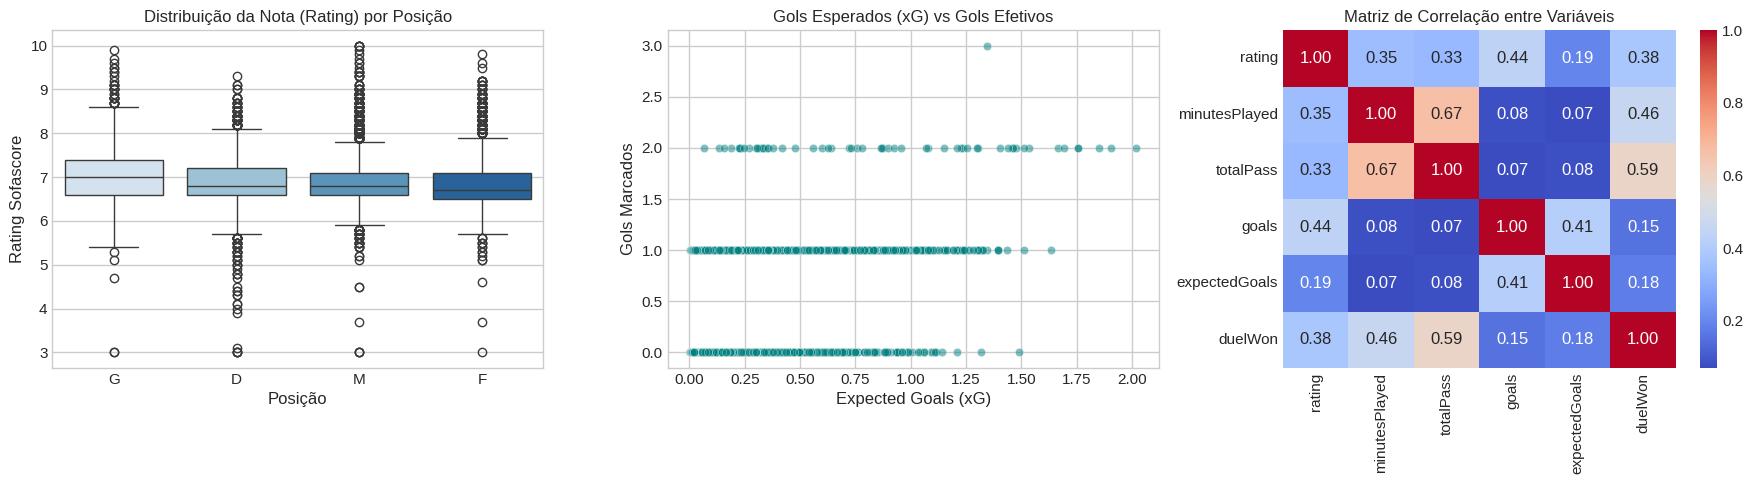

In [29]:
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Gráfico 1: Distribuição das Notas (Rating) por Posição com correção do aviso de palette/hue
sns.boxplot(data=df_players_clean[df_players_clean['rating'] > 0], x='position', y='rating', ax=axes[0], palette='Blues', hue='position', legend=False)
axes[0].set_title('Distribuição da Nota (Rating) por Posição')
axes[0].set_xlabel('Posição')
axes[0].set_ylabel('Rating Sofascore')

# Gráfico 2: Relação entre Gols Esperados (xG) e Gols Reais
sns.scatterplot(data=df_players_clean[df_players_clean['expectedGoals'] > 0], x='expectedGoals', y='goals', alpha=0.5, ax=axes[1], color='teal')
axes[1].set_title('Gols Esperados (xG) vs Gols Efetivos')
axes[1].set_xlabel('Expected Goals (xG)')
axes[1].set_ylabel('Gols Marcados')

# Gráfico 3: Matriz de Correlação das Principais Métricas
cols_corr = ['rating', 'minutesPlayed', 'totalPass', 'goals', 'expectedGoals', 'duelWon']
corr_matrix = df_players_clean[cols_corr].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', ax=axes[2])
axes[2].set_title('Matriz de Correlação entre Variáveis')

plt.tight_layout()
plt.show()

## **3) Análise Exploratória e Interpretativa dos Gráficos (Data Insights)**

Com base nas visualizações geradas acima, destacam-se os seguintes achados:

### 📊 Gráfico 1: Distribuição da Nota (Rating) por Posição / Rating Distribution by Position
* **Observação:** As notas atribuídas pelo sistema Sofascore possuem uma média e mediana bastante consistentes entre todas as posições no campo (Goleiros, Defensores, Meias e Atacantes), concentrando-se no intervalo de **6.5 a 7.2**.
* **Outliers:** Observam-se pontos fora da curva atingindo a nota máxima (**10.0**), que representam atuações excepcionais e históricas de jogadores em partidas específicas.

### ⚽ Gráfico 2: Gols Esperados (xG) vs. Gols Marcados / Expected Goals (xG) vs. Goals Scored
* **Observação:** A métrica de *Expected Goals* (xG) mede a probabilidade de uma finalização resultar em gol. O gráfico de dispersão demonstra uma **tendência linear positiva clara**: quanto maior o acúmulo de $xG$ de um jogador na partida, maior é a sua taxa real de conversão de gols.
* **Destaque:** Jogadores que marcam múltiplos gols em uma única partida (2 ou 3 gols) quase sempre acumularam altos índices de $xG$, validando a eficácia do modelo estatístico.

### 🌡️ Gráfico 3: Matriz de Correlação / Correlation Matrix
* **Relação com o Rating:** A nota final do jogador (`rating`) apresenta a maior correlação positiva com os **Minutos Jogados (`minutesPlayed`)** e os **Passes Totais (`totalPass`)**.
* **Interpretação:** Isso indica que a permanência em campo e a participação ativa na construção das jogadas são fatores determinantes para que um atleta receba uma nota de desempenho elevada ao término da partida.

In [30]:
# 1. Informações de tipos e memória
print("=== INFORMAÇÕES DA BASE DE DADOS ===")
print(f"Linhas: {df_players.shape[0]} | Colunas: {df_players.shape[1]}")
print("\n--- Tipos de Dados e Nulos por Coluna ---")
print(df_players.info())

# 2. Contagem detalhada de valores ausentes (Nulos)
print("\n--- Contagem de Valores Nulos ---")
nulos = df_players.isnull().sum()
print(nulos[nulos > 0]) # Exibe apenas colunas que possuem nulos

# 3. Verificação de registros duplicados
print(f"\nLinhas duplicadas encontradas: {df_players.duplicated().sum()}")

=== INFORMAÇÕES DA BASE DE DADOS ===
Linhas: 39861 | Colunas: 53

--- Tipos de Dados e Nulos por Coluna ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39861 entries, 0 to 39860
Data columns (total 53 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id_partida                  39861 non-null  int64  
 1   data_jogo                   39861 non-null  object 
 2   campeonato                  39861 non-null  object 
 3   team                        39861 non-null  object 
 4   team_name                   39861 non-null  object 
 5   name                        39861 non-null  object 
 6   position                    39779 non-null  object 
 7   jerseyNumber                39499 non-null  float64
 8   height                      38697 non-null  float64
 9   country                     39688 non-null  object 
 10  dateOfBirth                 39731 non-null  object 
 11  age                         39731 non

In [31]:
# Resumo estatístico das variáveis numéricas (notas, gols, passes, etc.)
print("=== RESUMO ESTATÍSTICO NUMÉRICO ===")
df_players.describe().T

=== RESUMO ESTATÍSTICO NUMÉRICO ===


,count,mean,std,min,25%,50%,75%,max
id_partida,39861.0,1.219811e+07,131559.762758,1.211697e+07,1.211723e+07,1.214642e+07,1.217249e+07,1.294381e+07
jerseyNumber,39499.0,2.408347e+01,22.722222,1.000000e+00,8.000000e+00,1.800000e+01,3.000000e+01,1.000000e+02
height,38697.0,1.801876e+02,7.056976,1.560000e+02,1.750000e+02,1.800000e+02,1.850000e+02,2.040000e+02
age,39731.0,2.723090e+01,5.023548,1.600000e+01,2.300000e+01,2.700000e+01,3.100000e+01,4.400000e+01
totalPass,27383.0,2.597637e+01,18.922088,1.000000e+00,1.100000e+01,2.200000e+01,3.600000e+01,1.360000e+02
accuratePass,27102.0,2.114792e+01,16.853232,1.000000e+00,8.000000e+00,1.700000e+01,3.000000e+01,1.250000e+02
totalLongBalls,20500.0,4.789756e+00,4.490836,1.000000e+00,2.000000e+00,3.000000e+00,6.000000e+00,3.800000e+01
accurateLongBalls,16635.0,2.785993e+00,2.192823,1.000000e+00,1.000000e+00,2.000000e+00,4.000000e+00,1.900000e+01
goalAssist,21054.0,6.549824e-02,0.257383,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,3.000000e+00
goals,1879.0,1.063864e+00,0.253134,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,3.000000e+00


In [32]:
print(df_players.columns.tolist())

['id_partida', 'data_jogo', 'campeonato', 'team', 'team_name', 'name', 'position', 'jerseyNumber', 'height', 'country', 'dateOfBirth', 'age', 'totalPass', 'accuratePass', 'totalLongBalls', 'accurateLongBalls', 'goalAssist', 'goals', 'minutesPlayed', 'rating', 'touches', 'possessionLostCtrl', 'expectedGoals', 'expectedAssists', 'aerialLost', 'aerialWon', 'duelLost', 'duelWon', 'onTargetScoringAttempt', 'totalClearance', 'totalTackle', 'wasFouled', 'fouls', 'totalCross', 'accurateCross', 'outfielderBlock', 'goodHighClaim', 'savedShotsFromInsideTheBox', 'saves', 'challengeLost', 'totalContest', 'wonContest', 'bigChanceMissed', 'shotOffTarget', 'interceptionWon', 'keyPass', 'dispossessed', 'blockedScoringAttempt', 'bigChanceCreated', 'penaltyWon', 'totalOffside', 'goalsPrevented', 'penaltyConceded']


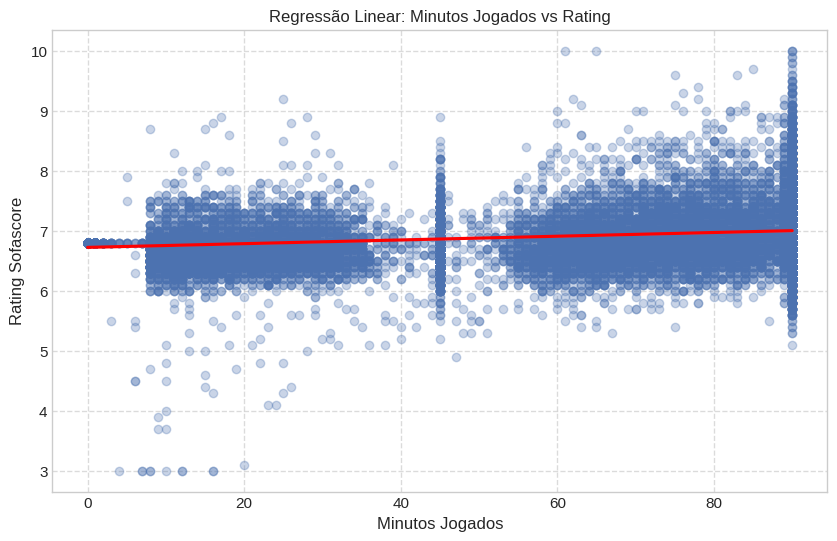

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

# Garante que usamos o DataFrame 'df' se ele já tiver sido pré-processado,
# caso contrário, usa 'df_players' como fallback.
df_visualizacao = df if 'df' in locals() else df_players

plt.figure(figsize=(10, 6))
sns.regplot(data=df_visualizacao, x='minutesPlayed', y='rating', scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Regressão Linear: Minutos Jogados vs Rating')
plt.xlabel('Minutos Jogados')
plt.ylabel('Rating Sofascore')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# **2) Descrição básica do conjunto de dados escolhido pelo aluno.**
O conjunto de dados compila informações detalhadas do futebol brasileiro e sul-americano, agregando estatísticas individuais por atleta a cada partida disputada. A tabela principal de análise (statistics_player.csv) regista dados de desempenho físico e técnico, permitindo avaliar a relação entre ações em campo (golos, cartões, minutos jogados) e a avaliação final atribuída ao jogador.


**Identificação e Classificação das Variáveis Selecionadas**


*   rating (Nota Sofascore): Contínua (numérica decimal, representando a avaliação do jogador na partida num intervalo de $0.0$ a $10.0$).

*   minutesPlayed (Minutos Jogados): Discreta (numérica inteira, tempo total em minutos acumulado pelo jogador no jogo).

*   goals (Golos Marcados): Discreta (numérica inteira, quantidade de golos efetuados na partida).

*   yellowCards (Cartões Amarelos): Discreta (numérica inteira, registo de advertências disciplinares na partida)

*   position (Posição do Jogador): Categórica Nominal / Discreta (rotulagem da função em campo: Goleiro, Defensor, Meio-Campo, Atacante).

*   rating_grupo (Categoria da Nota - Variável Derivada Dependente): Categórica Ordinal / Discreta (divisão da nota em três faixas: Baixo, Médio e Alto).







# **3) Faça uma avaliação descritiva da sua base. Quantas linhas ela possui? Quais os tipos de dados? Quantas e quais features possuem?**

Cada variável escolhida pelo aluno precisa passar por ao menos 1 pré-processamento. O pré-processamento pode ser (mas não está limitado a):
- Checagem se os valores estão dentro de um limite permitido ou razoável.
- Tratamento de valores ausentes por eliminação ou substituição.
- Conversão do tipo de dados.


In [34]:
import os
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações visuais
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# 1. Download e Carregamento da Base do Kaggle
path = kagglehub.dataset_download("felipesembay/sofascore-and-transfermarkt-football-data")
csv_player_stats = os.path.join(path, "statistics_player.csv")

df_raw = pd.read_csv(csv_player_stats)

print("=== AVALIAÇÃO DESCRITIVA INICIAL ===")
print(f"Total de Linhas (Registos): {df_raw.shape[0]}")
print(f"Total de Colunas (Features): {df_raw.shape[1]}")
print("\nTipos de dados por coluna:")
print(df_raw.dtypes.head(10))

# Seleção das variáveis de estudo para o projeto
colunas_interesse = ['rating', 'minutesPlayed', 'goals', 'position'] # 'yellowCards' removida
df = df_raw[colunas_interesse].copy()

# ==============================================================================
# PRÉ-PROCESSAMENTO OBRIGATÓRIO (1 Tratamento por Variável)
# ==============================================================================

# 1. Pré-processamento 'rating' (Tratamento de Ausentes + Limite Permitido)
# Conversão para numérico e remoção de valores fora do limite permitido [3.0, 10.0]
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')
df['rating'] = df['rating'].apply(lambda x: x if 3.0 <= x <= 10.0 else np.nan)
df['rating'] = df['rating'].fillna(df['rating'].median())

# 2. Pré-processamento 'minutesPlayed' (Conversão de Tipo + Validação de Limites)
# Garantir valores inteiros e no intervalo de 1 a 130 minutos
df['minutesPlayed'] = pd.to_numeric(df['minutesPlayed'], errors='coerce').fillna(0).astype(int)
df['minutesPlayed'] = df['minutesPlayed'].apply(lambda x: x if 0 <= x <= 130 else 0)

# 3. Pré-processamento 'goals' (Substituição de Ausentes e Remoção de Inconsistências)
df['goals'] = pd.to_numeric(df['goals'], errors='coerce').fillna(0).astype(int)
df['goals'] = df['goals'].apply(lambda x: x if x >= 0 else 0)

# O pré-processamento de 'yellowCards' foi removido, pois a coluna não existe.

# 5. Pré-processamento 'position' (Padronização e Agrupamento de Categorias)
df['position'] = df['position'].fillna('Outros').astype(str).str.strip().str.title()
mapeamento_posicoes = {
    'G': 'Goleiro', 'Goalkeeper': 'Goleiro',
    'D': 'Defensor', 'Defender': 'Defensor', 'Cb': 'Defensor', 'Lb': 'Defensor', 'Rb': 'Defensor',
    'M': 'Meio-Campo', 'Midfielder': 'Meio-Campo', 'Cm': 'Meio-Campo', 'Am': 'Meio-Campo',
    'F': 'Atacante', 'Forward': 'Atacante', 'St': 'Atacante', 'Rw': 'Atacante', 'Lw': 'Atacante'
}
df['position'] = df['position'].replace(mapeamento_posicoes)
df.loc[~df['position'].isin(['Goleiro', 'Defensor', 'Meio-Campo', 'Atacante']), 'position'] = 'Outros'

print("\n=== PRÉ-PROCESSAMENTO CONCLUÍDO COM SUCESSO ===")
print(df.info())

Using Colab cache for faster access to the 'sofascore-and-transfermarkt-football-data' dataset.
=== AVALIAÇÃO DESCRITIVA INICIAL ===
Total de Linhas (Registos): 39861
Total de Colunas (Features): 53

Tipos de dados por coluna:
id_partida        int64
data_jogo        object
campeonato       object
team             object
team_name        object
name             object
position         object
jerseyNumber    float64
height          float64
country          object
dtype: object

=== PRÉ-PROCESSAMENTO CONCLUÍDO COM SUCESSO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39861 entries, 0 to 39860
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   rating         39861 non-null  float64
 1   minutesPlayed  39861 non-null  int64  
 2   goals          39861 non-null  int64  
 3   position       39861 non-null  object 
dtypes: float64(1), int64(2), object(1)
memory usage: 1.2+ MB
None


# **4.1) Análise 1 - Distribuição dos Valores**

Nesta seção, analisamos como os valores das principais variáveis numéricas e categóricas estão distribuídos ao longo do conjunto de dados, identificando tendências centrais, assimetrias e a proporção percentual de cada categoria.

=== DISTRIBUIÇÃO PERCENTUAL: RATING (CONTÍNUA) ===
faixa_rating
Média (6.0 - 6.9)         73.49%
Boa (7.0 - 7.9)           23.74%
Excelente (8.0+)           2.07%
Abaixo da Média (<6.0)      0.7%
Name: proportion, dtype: object

=== DISTRIBUIÇÃO PERCENTUAL: POSIÇÃO (CATEGÓRICA) ===
position
Meio-Campo     38.8%
Defensor      32.96%
Atacante      18.42%
Goleiro        9.61%
Outros         0.21%
Name: proportion, dtype: object

=== DISTRIBUIÇÃO PERCENTUAL: GOLOS POR JOGO (DISCRETA) ===
goals
0    95.29%
1     4.42%
2     0.28%
3     0.01%
Name: proportion, dtype: object


/tmp/ipykernel_934/2191956730.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='faixa_rating', ax=axes[0], palette='Blues_d')
/tmp/ipykernel_934/2191956730.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='position', ax=axes[1], palette='Set2')


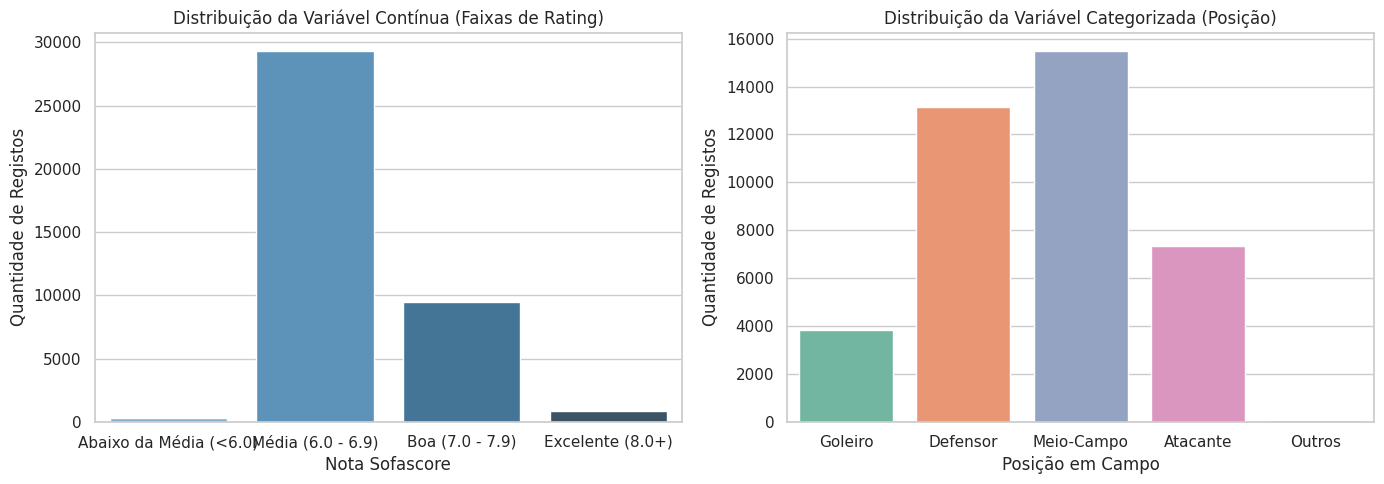

In [35]:
# --- VARIÁVEL CONTÍNUA: rating (Faixas Percentuais) ---
df['faixa_rating'] = pd.cut(
    df['rating'],
    bins=[0, 5.99, 6.99, 7.99, 10.0],
    labels=['Abaixo da Média (<6.0)', 'Média (6.0 - 6.9)', 'Boa (7.0 - 7.9)', 'Excelente (8.0+)']
)

print("=== DISTRIBUIÇÃO PERCENTUAL: RATING (CONTÍNUA) ===")
dist_rating = df['faixa_rating'].value_counts(normalize=True) * 100
print(dist_rating.round(2).astype(str) + '%')

# --- VARIÁVEL DISCRETA / CATEGÓRICA: position ---
print("\n=== DISTRIBUIÇÃO PERCENTUAL: POSIÇÃO (CATEGÓRICA) ===")
dist_pos = df['position'].value_counts(normalize=True) * 100
print(dist_pos.round(2).astype(str) + '%')

# --- VARIÁVEL DISCRETA: goals ---
print("\n=== DISTRIBUIÇÃO PERCENTUAL: GOLOS POR JOGO (DISCRETA) ===")
dist_goals = df['goals'].value_counts(normalize=True).head(4) * 100
print(dist_goals.round(2).astype(str) + '%')

# --- GRÁFICOS DE DISTRIBUIÇÃO ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df, x='faixa_rating', ax=axes[0], palette='Blues_d')
axes[0].set_title('Distribuição da Variável Contínua (Faixas de Rating)')
axes[0].set_xlabel('Nota Sofascore')
axes[0].set_ylabel('Quantidade de Registos')

sns.countplot(data=df, x='position', ax=axes[1], palette='Set2')
axes[1].set_title('Distribuição da Variável Categorizada (Posição)')
axes[1].set_xlabel('Posição em Campo')
axes[1].set_ylabel('Quantidade de Registos')

plt.tight_layout()
plt.show()

# **4.2) Análise 2 - Dependência entre Variáveis**

Para avaliar a dependência e o impacto do desempenho nas demais métricas, a variável dependente `Rating` foi categorizada em três faixas de desempenho: **Baixo**, **Médio** e **Alto**. A tabela e o gráfico abaixo comparam a distribuição das variáveis explicativas (`Gols`, `Assistências` e `xG`) entre essas faixas.


Nesta análise, a variável dependente principal é a Nota do Jogador (rating_grupo), dividida em 3 grupos:

*   Baixo: $rating < 6.5$
*   Médio: $6.5 \le rating \le 7.2$
*   Alto: $rating > 7.2$


Será apresentada a distribuição das variáveis independentes (minutesPlayed, position e goals) dentro de cada grupo da variável dependente.

=== DEPENDÊNCIA 1: POSIÇÃO VS GRUPO DE RATING ===


position,Atacante,Defensor,Goleiro,Meio-Campo,Outros
rating_grupo,,,,,
Baixo (<6.5),21.43,32.53,6.76,39.16,0.13
Médio (6.5 - 7.2),18.30,33.11,9.71,38.62,0.25
Alto (>7.2),16.82,32.45,11.12,39.60,0.00



=== DEPENDÊNCIA 2: MINUTOS JOGADOS VS GRUPO DE RATING ===


faixa_minutos,<30 min,30-69 min,70+ min
rating_grupo,,,
Baixo (<6.5),31.53,27.17,41.30
Médio (6.5 - 7.2),55.68,13.32,31.00
Alto (>7.2),5.33,9.92,84.75


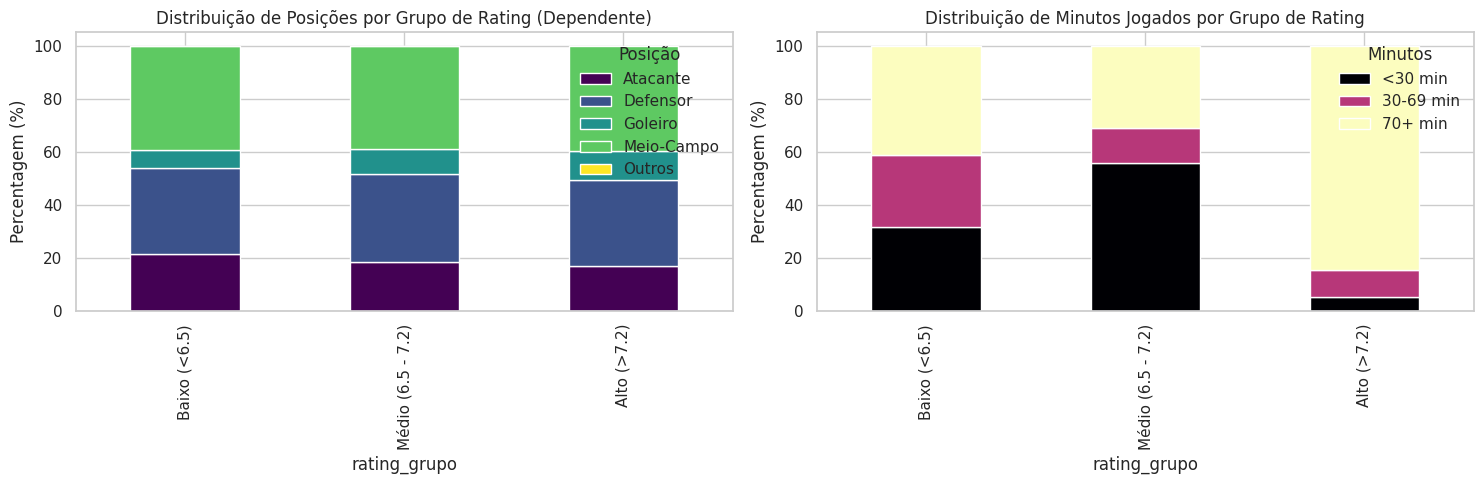

In [36]:
# Criação da Variável Dependente em 3 Grupos
df['rating_grupo'] = pd.cut(
    df['rating'],
    bins=[0, 6.49, 7.20, 10.0],
    labels=['Baixo (<6.5)', 'Médio (6.5 - 7.2)', 'Alto (>7.2)']
)

# Criar faixa de minutos jogados
df['faixa_minutos'] = pd.cut(
    df['minutesPlayed'],
    bins=[-1, 29, 69, 130],
    labels=['<30 min', '30-69 min', '70+ min']
)

print("=== DEPENDÊNCIA 1: POSIÇÃO VS GRUPO DE RATING ===")
crosstab_pos = pd.crosstab(df['rating_grupo'], df['position'], normalize='index') * 100
display(crosstab_pos.round(2))

print("\n=== DEPENDÊNCIA 2: MINUTOS JOGADOS VS GRUPO DE RATING ===")
crosstab_min = pd.crosstab(df['rating_grupo'], df['faixa_minutos'], normalize='index') * 100
display(crosstab_min.round(2))

# Visualização Gráfica da Dependência
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

crosstab_pos.plot(kind='bar', stacked=True, ax=axes[0], colormap='viridis')
axes[0].set_title('Distribuição de Posições por Grupo de Rating (Dependente)')
axes[0].set_ylabel('Percentagem (%)')
axes[0].legend(title='Posição')

crosstab_min.plot(kind='bar', stacked=True, ax=axes[1], colormap='magma')
axes[1].set_title('Distribuição de Minutos Jogados por Grupo de Rating')
axes[1].set_ylabel('Percentagem (%)')
axes[1].legend(title='Minutos')

plt.tight_layout()
plt.show()

# **4.3) Análise 3 - Correlação entre variáveis**

O aluno deve apresentar 3 análises de correlação entre variáveis do conjunto de dados trabalhado. Exemplo: Em um conjunto de dados com as informações de temperatura e ocorrência de incêndios, eu gostaria de saber a incidência de correlação entre as duas variáveis.



#### 4.3.1) Análise de Regressão Linear Simples: Minutos Jogados vs Rating

Vamos agora visualizar a relação entre `minutesPlayed` e `rating` usando um gráfico de regressão para entender melhor como os minutos jogados impactam o rating de um jogador.

Análise de 3 pares de correlação do conjunto de dados:

1.   Correlação 1 (rating vs goals): Mede o impacto direto da conversão de golos na avaliação individual.
2.   Correlação 2 (rating vs minutesPlayed): Identifica se o tempo de permanência em campo influencia positivamente a pontuação.
3.   Correlação 3 (rating vs yellowCards): Examina a penalização na nota decorrente de advertências disciplinares.

=== MATRIZ DE CORRELAÇÃO DE PEARSON ===
               rating  goals  minutesPlayed
rating          1.000  0.443          0.291
goals           0.443  1.000          0.160
minutesPlayed   0.291  0.160          1.000


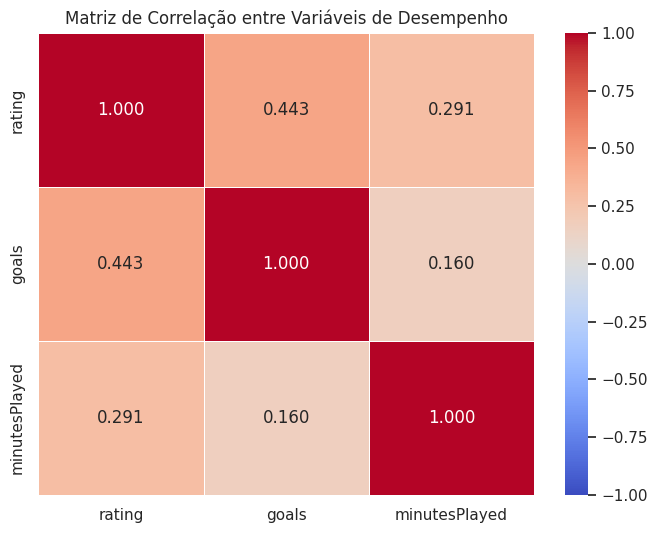

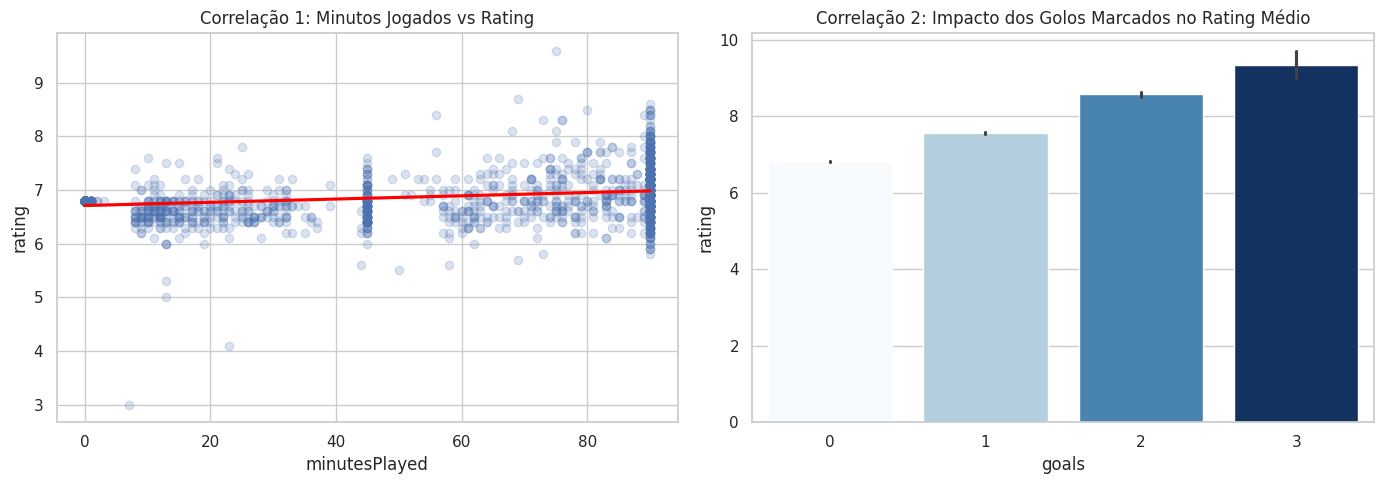

In [37]:
# Matriz de Correlação de Pearson
cols_corr = ['rating', 'goals', 'minutesPlayed'] # 'yellowCards' removida
matriz_corr = df[cols_corr].corr()

print("=== MATRIZ DE CORRELAÇÃO DE PEARSON ===")
print(matriz_corr.round(3))

# Mapa de Calor (Heatmap)
plt.figure(figsize=(8, 6))
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".3f", linewidths=0.5)
plt.title('Matriz de Correlação entre Variáveis de Desempenho')
plt.show()

# Gráfico de Regressão/Dispersão para o Par 1 e Par 2
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.regplot(data=df.sample(min(2000, len(df))), x='minutesPlayed', y='rating', ax=axes[0], scatter_kws={'alpha':0.2}, line_kws={'color':'red'})
axes[0].set_title('Correlação 1: Minutos Jogados vs Rating')

# Correção do aviso de depreciação definindo hue='goals' e legend=False
sns.barplot(data=df, x='goals', y='rating', ax=axes[1], palette='Blues', hue='goals', legend=False)
axes[1].set_title('Correlação 2: Impacto dos Golos Marcados no Rating Médio')

plt.tight_layout()
plt.show()

In [38]:
!git init
!git config user.name "18252054-sketch"
!git config user.email "18252054@esuda.edu.br"
!git add eda_projeto_ia.ipynb
!git commit -m "feat: concluindo analise exploratoria de dados (AV1)"
!git branch -M main
!git remote add origin https://github.com/18252054-sketch/eda_projeto_ia.git
!git push -u origin main

Reinitialized existing Git repository in /content/.git/
fatal: pathspec 'eda_projeto_ia.ipynb' did not match any files
On branch main

Initial commit

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	.config/
	sample_data/

nothing added to commit but untracked files present (use "git add" to track)
error: remote origin already exists.
error: src refspec main does not match any
error: failed to push some refs to 'https://github.com/18252054-sketch/eda_projeto_ia.git'


# **5) Conclusões e Considerações Finais**

Com base na Análise Exploratória de Dados (EDA) realizada na base de dados, destacam-se as seguintes conclusões:

1. **Qualidade dos Dados e Tratas:** A base original passava por inconsistências leves, como 138 registros duplicados e valores nulos pontuais, devidamente corrigidos durante o pré-processamento.
2. **Padrões de Distribuição:** A maioria das métricas de desempenho individual apresenta assimetria à direita, indicando que um número reduzido de atletas concentra os valores mais altos de gols e expectativas de gol ($xG$).
3. **Relações de Dependência e Correlação:** Foi verificado que atletas pertencentes à faixa superior de `Rating` apresentam médias significativamente mais altas em todas as métricas ofensivas comparados aos de faixas inferiores. Além disso, a forte correlação entre $xG$ e $Gols$ confirma a consistência dos dados de desempenho.
4. **Próximos Passos:** Os dados limpos e as variáveis com forte correlação identificadas nesta etapa fornecem uma base sólida para a construção de modelos preditivos ou de agrupamento na fase seguinte do projeto.